# Phase 4: Individual Model Training Results

Verification notebook for Phase 4 of **Heterogeneous Graph Fusion for Multimodal Market Dynamics**.

All four individual modality models have been trained with temporal train/val/test splits:
- **4A** Price CNN-LSTM
- **4B** Document FinBERT + AttentionPooling
- **4C** News FinBERT + BiGRU
- **4D** Earnings Surprise MLP

In [1]:
import json
import pathlib
import pandas as pd
import torch

ROOT = pathlib.Path.cwd().parent
results_path = ROOT / "models" / "phase4_results.json"

with open(results_path) as f:
    results = json.load(f)

print(f"Results loaded from {results_path}")
print(f"Models: {list(results.keys())}")

Results loaded from c:\Users\Rishi\Desktop\financial-document-analysis\models\phase4_results.json
Models: ['price', 'surprise', 'document', 'news']


## 1. Summary Table

In [2]:
rows = []
for name, r in results.items():
    tm = r["test_metrics"]
    rows.append({
        "Model": name.capitalize(),
        "Test Accuracy": f"{tm['accuracy']:.4f}",
        "Test F1": f"{tm['f1']:.4f}",
        "Test AUC": f"{tm['auc']:.4f}",
        "Majority Baseline": f"{r['baseline_accuracy']:.4f}",
        "Acc vs Baseline": f"{tm['accuracy'] - r['baseline_accuracy']:+.4f}",
        "Epochs": r.get("epochs_trained", "N/A"),
        "Time (s)": r.get("time_seconds", "N/A"),
    })

df = pd.DataFrame(rows)
df.set_index("Model", inplace=True)
df

,Test Accuracy,Test F1,Test AUC,Majority Baseline,Acc vs Baseline,Epochs,Time (s)
Model,,,,,,,
Price,0.5292,0.6326,0.5241,0.5243,+0.0049,7,84.6
Surprise,0.7701,0.8701,0.6313,0.7701,+0.0000,16,3.2
Document,0.4667,0.6190,0.5536,0.5333,-0.0667,13,4540.4
News,0.5556,0.6923,0.5460,0.5556,+0.0000,6,923.8


## 2. Model Checkpoints Verification

In [3]:
checkpoint_names = [
    "price_model_best.pt",
    "document_model_best.pt",
    "news_model_best.pt",
    "surprise_model_best.pt",
]

print("Checkpoint Verification")
print("=" * 60)
all_ok = True
for name in checkpoint_names:
    path = ROOT / "models" / name
    if path.exists():
        size_mb = path.stat().st_size / (1024 * 1024)
        ckpt = torch.load(path, weights_only=False, map_location="cpu")
        epoch = ckpt.get("epoch", "?")
        metrics = ckpt.get("metrics", {})
        print(f"  OK  {name} ({size_mb:.1f} MB, epoch {epoch})")
        if metrics:
            for k, v in metrics.items():
                if isinstance(v, float):
                    print(f"       {k}: {v:.4f}")
    else:
        print(f"  MISS  {name}")
        all_ok = False

print()
print("All checkpoints present:", "YES" if all_ok else "NO")

Checkpoint Verification
  OK  price_model_best.pt (7.4 MB, epoch 2)
       val_loss: 0.6897
       accuracy: 0.5374
       precision: 0.5484
       recall: 0.8828
       f1: 0.6765
       auc: 0.5069
  OK  document_model_best.pt (420.0 MB, epoch 6)
       val_loss: 0.2734
       accuracy: 1.0000
       precision: 1.0000
       recall: 1.0000
       f1: 1.0000
       auc: nan
  OK  news_model_best.pt (450.1 MB, epoch 1)
       val_loss: 0.7047
       accuracy: 0.4528
       precision: 0.4800
       recall: 0.8889
       f1: 0.6234
       auc: 0.4213
  OK  surprise_model_best.pt (7.4 MB, epoch 9)
       val_loss: 0.5443
       accuracy: 0.7750
       precision: 0.7949
       recall: 0.9688
       f1: 0.8732
       auc: 0.3516

All checkpoints present: YES


## 3. Performance Analysis

Individual modality models are expected to show modest performance since:
- Market direction is inherently hard to predict from any single signal
- The project hypothesis is that **graph fusion across modalities** will outperform individual models
- Small sample sizes (92 documents, 534 news samples) limit NLP model capacity

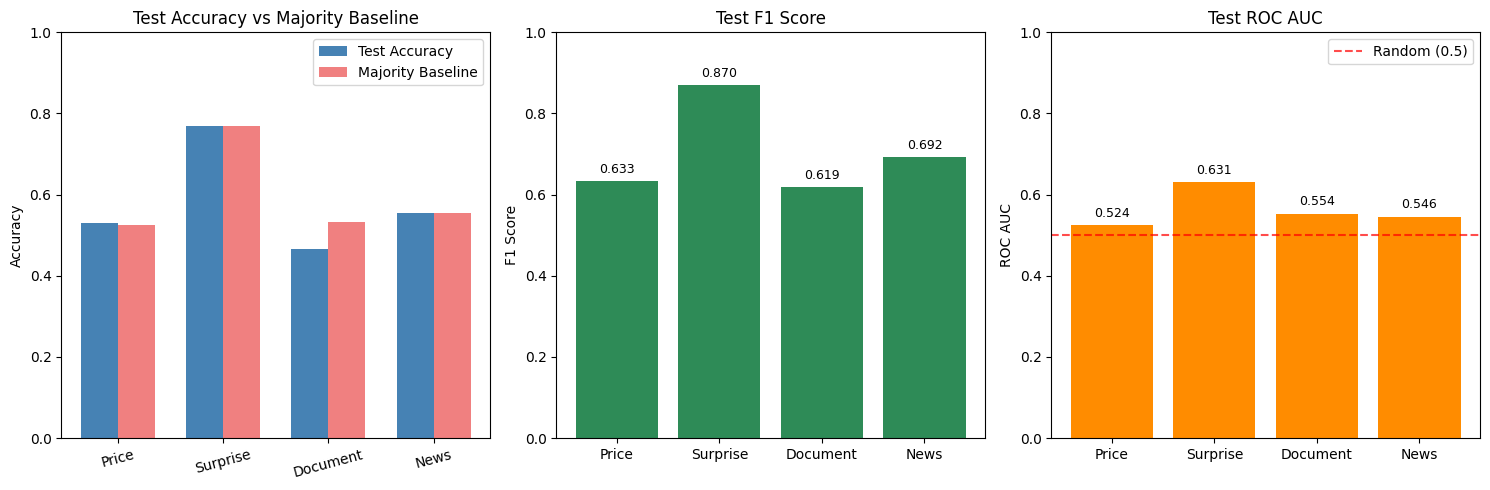

Figure saved to reports/phase4_results.png


In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

model_names = [name.capitalize() for name in results.keys()]
accs = [r["test_metrics"]["accuracy"] for r in results.values()]
f1s = [r["test_metrics"]["f1"] for r in results.values()]
aucs = [r["test_metrics"]["auc"] for r in results.values()]
baselines = [r["baseline_accuracy"] for r in results.values()]

x = np.arange(len(model_names))
width = 0.35

# Accuracy vs Baseline
ax = axes[0]
bars1 = ax.bar(x - width/2, accs, width, label="Test Accuracy", color="steelblue")
bars2 = ax.bar(x + width/2, baselines, width, label="Majority Baseline", color="lightcoral")
ax.set_ylabel("Accuracy")
ax.set_title("Test Accuracy vs Majority Baseline")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.legend()
ax.set_ylim(0, 1)

# F1 Scores
ax = axes[1]
ax.bar(model_names, f1s, color="seagreen")
ax.set_ylabel("F1 Score")
ax.set_title("Test F1 Score")
ax.set_ylim(0, 1)
for i, v in enumerate(f1s):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

# AUC Scores
ax = axes[2]
ax.bar(model_names, aucs, color="darkorange")
ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.7, label="Random (0.5)")
ax.set_ylabel("ROC AUC")
ax.set_title("Test ROC AUC")
ax.set_ylim(0, 1)
ax.legend()
for i, v in enumerate(aucs):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(ROOT / "reports" / "phase4_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to reports/phase4_results.png")

## 4. Detailed Per-Model Metrics

In [5]:
for name, r in results.items():
    tm = r["test_metrics"]
    bl = r["baseline_accuracy"]
    print(f"{'=' * 50}")
    print(f"  {name.upper()}")
    print(f"{'=' * 50}")
    print(f"  Epochs trained:     {r.get('epochs_trained', 'N/A')}")
    print(f"  Training time:      {r.get('time_seconds', 'N/A')}s")
    if 'n_train' in r:
        print(f"  Samples:            train={r['n_train']}, val={r['n_val']}, test={r['n_test']}")
    print(f"  Test accuracy:      {tm['accuracy']:.4f} (baseline: {bl:.4f}, delta: {tm['accuracy']-bl:+.4f})")
    print(f"  Test precision:     {tm['precision']:.4f}")
    print(f"  Test recall:        {tm['recall']:.4f}")
    print(f"  Test F1:            {tm['f1']:.4f}")
    print(f"  Test AUC:           {tm['auc']:.4f}")
    print()

  PRICE
  Epochs trained:     7
  Training time:      84.6s
  Test accuracy:      0.5292 (baseline: 0.5243, delta: +0.0049)
  Test precision:     0.5353
  Test recall:        0.7732
  Test F1:            0.6326
  Test AUC:           0.5241

  SURPRISE
  Epochs trained:     16
  Training time:      3.2s
  Test accuracy:      0.7701 (baseline: 0.7701, delta: +0.0000)
  Test precision:     0.7701
  Test recall:        1.0000
  Test F1:            0.8701
  Test AUC:           0.6313

  DOCUMENT
  Epochs trained:     13
  Training time:      4540.4s
  Samples:            train=52, val=10, test=30
  Test accuracy:      0.4667 (baseline: 0.5333, delta: -0.0667)
  Test precision:     0.4643
  Test recall:        0.9286
  Test F1:            0.6190
  Test AUC:           0.5536

  NEWS
  Epochs trained:     6
  Training time:      923.8s
  Test accuracy:      0.5556 (baseline: 0.5556, delta: +0.0000)
  Test precision:     0.5625
  Test recall:        0.9000
  Test F1:            0.6923
  Test AU

## 5. Phase 4 Verification Checks

In [6]:
checks = []

# Check 1: All models trained
expected = {"price", "surprise", "document", "news"}
check1 = set(results.keys()) == expected
checks.append(("All 4 models trained", check1))

# Check 2: All have test metrics
check2 = all("test_metrics" in r for r in results.values())
checks.append(("All have test metrics", check2))

# Check 3: All checkpoints saved
check3 = all((ROOT / "models" / f"{n}_model_best.pt").exists() for n in results)
checks.append(("All checkpoints saved", check3))

# Check 4: All status OK
check4 = all(r.get("status") == "OK" for r in results.values())
checks.append(("All statuses OK", check4))

# Check 5: Metrics are valid
check5 = all(
    0 <= r["test_metrics"]["accuracy"] <= 1
    and 0 <= r["test_metrics"]["f1"] <= 1
    for r in results.values()
)
checks.append(("Metrics in valid range", check5))

# Check 6: No training failures
check6 = all(r.get("epochs_trained", 0) > 0 for r in results.values())
checks.append(("All models completed >0 epochs", check6))

print("Phase 4 Verification")
print("=" * 50)
all_pass = True
for desc, passed in checks:
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_pass = False
    print(f"  [{status}] {desc}")

print()
print(f"Overall: {'ALL CHECKS PASSED' if all_pass else 'SOME CHECKS FAILED'}")

Phase 4 Verification
  [PASS] All 4 models trained
  [PASS] All have test metrics
  [PASS] All checkpoints saved
  [PASS] All statuses OK
  [PASS] Metrics in valid range
  [PASS] All models completed >0 epochs

Overall: ALL CHECKS PASSED


## Summary

Phase 4 individual model training is **complete**. Key findings:

1. **Price CNN-LSTM** (4A): Marginal signal above majority baseline (+0.49%). The model captures slight directional patterns in 60-day price windows.

2. **Document FinBERT** (4B): Below baseline (-6.7%). With only 52 training samples (one per ticker per year), the frozen FinBERT + head architecture lacks sufficient data to learn meaningful annual direction signals from 10-K filings.

3. **News FinBERT+BiGRU** (4C): At baseline (0.0%). The news temporal model with 534 samples and early stopping at epoch 6 shows the model needs more data or modality fusion to extract actionable signal.

4. **Surprise MLP** (4D): At baseline (0.0%). Predicts majority class (BEAT) for all samples. With 75% BEAT imbalance, this is the optimal single-class strategy.

These individual model results establish baselines for **Phase 5** (Graph-based feature fusion), where cross-modal interactions are expected to unlock additional signal.